In [37]:
# ============================================
# MASTER IMPORTS — covers everything needed
# for all remaining cells in this notebook
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import pickle
import os
import warnings

from collections import Counter
from itertools import combinations

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    LeaveOneOut
)
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)
from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression
)
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier
)
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.feature_extraction.text import (
    TfidfVectorizer
)
from sklearn.pipeline import Pipeline
from scipy.sparse import hstack, csr_matrix

import xgboost as xgb

warnings.filterwarnings("ignore")

# ============================================
# SKILL FUNCTIONS — reusable across all cells
# ============================================

SKILLS = {
    "python", "sql", "r", "java", "scala",
    "matlab", "javascript", "sas", "stata",
    "tensorflow", "pytorch", "keras",
    "scikit-learn", "xgboost", "lightgbm",
    "huggingface", "transformers",
    "spark", "hadoop", "kafka", "airflow",
    "dbt", "pandas", "numpy", "dask",
    "postgresql", "mysql", "mongodb",
    "snowflake", "bigquery", "redshift",
    "databricks", "aws", "gcp", "azure",
    "docker", "kubernetes", "mlflow",
    "nlp", "bert", "gpt", "llm", "spacy",
    "langchain", "word2vec", "embeddings",
    "tableau", "power bi", "matplotlib",
    "plotly", "looker",
    "machine learning", "deep learning",
    "neural network", "regression",
    "classification", "clustering",
    "computer vision", "time series",
    "a/b testing", "statistics",
    "git", "github", "agile", "excel"
}

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[•·▪▸●◦]", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s\+\#\/\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def extract_skills(text):
    cleaned = clean_text(text)
    found = []
    for skill in SKILLS:
        pattern = r"\b" + re.escape(skill) + r"\b"
        if re.search(pattern, cleaned):
            found.append(skill)
    return found

def extract_year(date_val, source):
    try:
        return int(str(date_val).strip()[:4])
    except:
        return None

def extract_seniority(title):
    title_lower = str(title).lower()
    if any(w in title_lower for w in
           ["principal", "staff", "distinguished"]):
        return 4
    elif any(w in title_lower for w in
             ["senior", "sr", "lead", "manager"]):
        return 3
    elif any(w in title_lower for w in
             ["mid", "intermediate", "ii", "2"]):
        return 2
    elif any(w in title_lower for w in
             ["junior", "jr", "entry",
              "associate", "i "]):
        return 1
    else:
        return 2

def extract_job_family(title):
    title_lower = str(title).lower()
    if any(w in title_lower for w in
           ["machine learning", "ml engineer", "mlops"]):
        return "ml_engineer"
    elif any(w in title_lower for w in
             ["data scientist", "applied scientist",
              "research scientist"]):
        return "data_scientist"
    elif any(w in title_lower for w in
             ["data analyst", "analytics"]):
        return "data_analyst"
    elif any(w in title_lower for w in
             ["data engineer", "etl", "pipeline"]):
        return "data_engineer"
    elif any(w in title_lower for w in
             ["nlp", "natural language", "text"]):
        return "nlp_engineer"
    else:
        return "other"

def assign_role_label(title):
    title_lower = str(title).lower()
    if any(w in title_lower for w in [
        "machine learning engineer", "ml engineer",
        "mlops", "machine learning",
        "computer vision", "cv engineer",
        "deep learning engineer", "ai engineer",
        "artificial intelligence engineer",
        "general engineer", "software engineer"
    ]):
        return "machine learning engineer"
    elif any(w in title_lower for w in [
        "data scientist", "applied scientist",
        "research scientist", "staff scientist",
        "data science manager", "data science lead",
        "data science consultant",
        "data science director",
        "quantitative analyst",
        "quantitative researcher",
        "research engineer", "applied researcher",
        "decision scientist", "head of data science",
        "director of data science",
        "operations research", "statistician",
        "statistical analyst"
    ]):
        return "data scientist"
    elif any(w in title_lower for w in [
        "data analyst", "business analyst",
        "analytics analyst", "business intelligence",
        "reporting analyst", "bi developer",
        "bi analyst", "analytics manager",
        "data analytics manager", "insights analyst",
        "marketing analyst", "product analyst",
        "data specialist", "analytics specialist",
        "reporting specialist", "data quality analyst",
        "management analyst", "program analyst",
        "policy analyst", "financial analyst",
        "operations analyst", "systems analyst"
    ]):
        return "data analyst"
    elif any(w in title_lower for w in [
        "data engineer", "etl engineer",
        "pipeline engineer", "analytics engineer",
        "database engineer", "data architect",
        "data infrastructure", "data platform",
        "data warehouse", "data modeler",
        "data manager", "data operations",
        "dataops", "data reliability",
        "etl developer", "head of data",
        "director of data", "data lead"
    ]):
        return "data engineer"
    elif any(w in title_lower for w in [
        "nlp", "natural language",
        "computational linguist",
        "text analytics", "text mining",
        "conversational ai", "speech"
    ]):
        return "nlp engineer"
    else:
        return "other"

print("=" * 50)
print("All imports and functions loaded!")
print(f"Tracking {len(SKILLS)} skills")
print("Ready to run all cells")
print("=" * 50)

All imports and functions loaded!
Tracking 65 skills
Ready to run all cells


In [38]:
# Load the combined dataset from data integration
combined_df = pd.read_csv("../data/raw/jobs_combined.csv")

print(f"Combined dataset: {len(combined_df)} jobs")
print(f"Columns: {combined_df.columns.tolist()}")
print(f"\nJobs by source:")
print(combined_df["source"].value_counts())

# Separate jobs with and without salary
salary_df = combined_df.dropna(
    subset=["salary_min", "salary_max"]
).copy()
salary_df["salary_avg"] = (
    salary_df["salary_min"] + salary_df["salary_max"]
) / 2

print(f"\nJobs with salary: {len(salary_df)}")
print(f"Salary range: ${salary_df['salary_avg'].min():,.0f}"
      f" — ${salary_df['salary_avg'].max():,.0f}")
print(f"Average: ${salary_df['salary_avg'].mean():,.0f}")

Combined dataset: 2249 jobs
Columns: ['title', 'company', 'location', 'remote', 'description', 'salary_min', 'salary_max', 'date_posted', 'source']

Jobs by source:
source
kaggle         1713
usajobs_api     347
jsearch_api     189
Name: count, dtype: int64

Jobs with salary: 2108
Salary range: $30,000 — $550,000
Average: $147,387


In [39]:
# Experience level signals from job title
# These are strong salary predictors
def extract_seniority(title):
    title_lower = str(title).lower()
    if any(w in title_lower for w in 
           ["principal", "staff", "distinguished"]):
        return 4   # highest
    elif any(w in title_lower for w in 
             ["senior", "sr", "lead", "manager"]):
        return 3
    elif any(w in title_lower for w in 
             ["mid", "intermediate", "ii", "2"]):
        return 2
    elif any(w in title_lower for w in 
             ["junior", "jr", "entry", "associate", "i "]):
        return 1
    else:
        return 2   # assume mid level if unclear

# Job family from title
def extract_job_family(title):
    title_lower = str(title).lower()
    if any(w in title_lower for w in 
           ["machine learning", "ml engineer", "mlops"]):
        return "ml_engineer"
    elif any(w in title_lower for w in 
             ["data scientist", "applied scientist"]):
        return "data_scientist"
    elif any(w in title_lower for w in 
             ["data analyst", "analytics"]):
        return "data_analyst"
    elif any(w in title_lower for w in 
             ["data engineer", "etl", "pipeline"]):
        return "data_engineer"
    elif any(w in title_lower for w in 
             ["nlp", "natural language", "text"]):
        return "nlp_engineer"
    else:
        return "other"

# Apply to salary dataframe
salary_df["seniority"] = salary_df["title"].apply(
    extract_seniority
)
salary_df["job_family"] = salary_df["title"].apply(
    extract_job_family
)

# Source encoding
# Different sources have different salary distributions
source_map = {
    "jsearch_api":  0,
    "kaggle":       1,
    "usajobs_api":  2
}
salary_df["source_encoded"] = salary_df["source"].map(
    source_map
)

# Job family encoding
family_map = {
    "ml_engineer":    0,
    "data_scientist": 1,
    "data_analyst":   2,
    "data_engineer":  3,
    "nlp_engineer":   4,
    "other":          5
}
salary_df["family_encoded"] = salary_df["job_family"].map(
    family_map
)

# Remote encoding
salary_df["is_remote"] = salary_df["remote"].apply(
    lambda x: 1 if x == True or x == "True" else 0
)

print("Feature engineering complete!")
print(f"\nSeniority distribution:")
print(salary_df["seniority"].value_counts().sort_index())
print(f"\nJob family distribution:")
print(salary_df["job_family"].value_counts())

Feature engineering complete!

Seniority distribution:
seniority
1     133
2     738
3    1226
4      11
Name: count, dtype: int64

Job family distribution:
job_family
other             644
data_engineer     434
data_scientist    401
data_analyst      396
ml_engineer       219
nlp_engineer       14
Name: count, dtype: int64


In [40]:
# Job titles contain the richest salary signal
# "Senior Principal Data Scientist" vs 
# "Junior Data Analyst" — huge salary difference

tfidf = TfidfVectorizer(
    max_features=50,        # top 50 most informative words
    ngram_range=(1, 2),     # single words and pairs
    stop_words="english",
    min_df=3                # must appear in at least 3 jobs
)

# Fit on ALL jobs, not just salary ones
# gives better vocabulary coverage
tfidf.fit(combined_df["title"].fillna(""))

# Transform salary jobs
title_features = tfidf.transform(
    salary_df["title"].fillna("")
)

print(f"TF-IDF vocabulary size: {len(tfidf.vocabulary_)}")
print(f"\nTop title terms:")
print(tfidf.get_feature_names_out()[:20])
print(f"\nTitle feature matrix: {title_features.shape}")

TF-IDF vocabulary size: 50

Top title terms:
['ai' 'analyst' 'analytics' 'analytics engineer' 'applied'
 'applied scientist' 'architect' 'data' 'data analyst' 'data architect'
 'data engineer' 'data science' 'data scientist' 'engineer' 'entry'
 'entry level' 'executive' 'executive data' 'lead' 'learning']

Title feature matrix: (2108, 50)


In [41]:
# Structured features
structured_features = salary_df[[
    "seniority",
    "family_encoded", 
    "source_encoded",
    "is_remote"
]].values

# Combine structured + TF-IDF title features
X = hstack([
    csr_matrix(structured_features),
    title_features
]).toarray()

# Target — salary
y = salary_df["salary_avg"].values

print(f"Feature matrix shape: {X.shape}")
print(f"  {X.shape[0]} jobs × {X.shape[1]} features")
print(f"  (4 structured + 50 TF-IDF title features)")
print(f"\nTarget (salary) stats:")
print(f"  Min:  ${y.min():,.0f}")
print(f"  Max:  ${y.max():,.0f}")
print(f"  Mean: ${y.mean():,.0f}")
print(f"  Std:  ${y.std():,.0f}")

# Train test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"\nTraining set: {X_train.shape[0]} jobs")
print(f"Testing set:  {X_test.shape[0]} jobs")

Feature matrix shape: (2108, 54)
  2108 jobs × 54 features
  (4 structured + 50 TF-IDF title features)

Target (salary) stats:
  Min:  $30,000
  Max:  $550,000
  Mean: $147,387
  Std:  $57,572

Training set: 1686 jobs
Testing set:  422 jobs


In [42]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        random_state=42,
        verbosity=0
    )
}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

results = {}

print("Training models on 2,108 salary data points...")

for name, model in models.items():
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        cv = cross_val_score(
            model, X_train_scaled, y_train,
            cv=5, scoring="r2"
        )
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cv = cross_val_score(
            model, X_train, y_train,
            cv=5, scoring="r2"
        )

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results[name] = {
        "rmse": rmse,
        "r2": r2,
        "cv_mean": cv.mean(),
        "cv_std": cv.std(),
        "predictions": y_pred,
        "model": model
    }

    print(f"\n{name}:")
    print(f"  RMSE:         ${rmse:,.0f}")
    print(f"  R²:           {r2:.3f}")
    print(f"  CV R² (5-fold): {cv.mean():.3f} "
          f"(+/- {cv.std():.3f})")

Training models on 2,108 salary data points...

Linear Regression:
  RMSE:         $48,173
  R²:           0.262
  CV R² (5-fold): 0.201 (+/- 0.069)

Random Forest:
  RMSE:         $47,290
  R²:           0.289
  CV R² (5-fold): 0.215 (+/- 0.059)

XGBoost:
  RMSE:         $47,741
  R²:           0.275
  CV R² (5-fold): 0.202 (+/- 0.072)


In [43]:
# Cell 7 — Train separate model per source

print("Training source-specific models...")

source_results = {}

for source in ["kaggle", "usajobs_api", "jsearch_api"]:
    source_data = salary_df[
        salary_df["source"] == source
    ].copy()
    
    if len(source_data) < 50:
        print(f"\n{source}: too few samples ({len(source_data)}), skipping")
        continue
    
    # Build features for this source
    title_feat = tfidf.transform(
        source_data["title"].fillna("")
    )
    struct_feat = source_data[[
        "seniority", "family_encoded",
        "source_encoded", "is_remote"
    ]].values
    
    X_src = hstack([
        csr_matrix(struct_feat),
        title_feat
    ]).toarray()
    
    y_src = source_data["salary_avg"].values
    
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_src, y_src,
        test_size=0.2,
        random_state=42
    )
    
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=3,
        random_state=42
    )
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    cv   = cross_val_score(
        model, X_src, y_src,
        cv=5, scoring="r2"
    )
    
    source_results[source] = {
        "rmse": rmse, "r2": r2,
        "cv_mean": cv.mean(),
        "n_samples": len(source_data),
        "model": model
    }
    
    print(f"\n{source} ({len(source_data)} jobs):")
    print(f"  RMSE:           ${rmse:,.0f}")
    print(f"  R²:             {r2:.3f}")
    print(f"  CV R² (5-fold): {cv.mean():.3f}")

Training source-specific models...

kaggle (1713 jobs):
  RMSE:           $58,196
  R²:             0.158
  CV R² (5-fold): 0.199

usajobs_api (347 jobs):
  RMSE:           $27,612
  R²:             0.185
  CV R² (5-fold): 0.002

jsearch_api: too few samples (48), skipping


In [44]:
# One-hot encode the source column
# Instead of source=0,1,2 (ordinal, implies ordering)
# Use three binary columns (no implied ordering)

source_dummies = pd.get_dummies(
    salary_df["source"],
    prefix="source"
).values

# Rebuild feature matrix with source dummies
X_v2 = hstack([
    csr_matrix(salary_df[[
        "seniority",
        "family_encoded",
        "is_remote"
    ]].values),
    csr_matrix(source_dummies),
    title_features
]).toarray()

y_v2 = salary_df["salary_avg"].values

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_v2, y_v2,
    test_size=0.2,
    random_state=42
)

# Train XGBoost with better hyperparameters
xgb_v2 = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    verbosity=0
)

xgb_v2.fit(X_tr2, y_tr2)
y_pred_v2 = xgb_v2.predict(X_te2)

rmse_v2 = np.sqrt(mean_squared_error(y_te2, y_pred_v2))
r2_v2   = r2_score(y_te2, y_pred_v2)
cv_v2   = cross_val_score(
    xgb_v2, X_v2, y_v2,
    cv=5, scoring="r2"
)

print("XGBoost v2 — with source one-hot encoding:")
print(f"  RMSE:           ${rmse_v2:,.0f}")
print(f"  R²:             {r2_v2:.3f}")
print(f"  CV R² (5-fold): {cv_v2.mean():.3f}")


XGBoost v2 — with source one-hot encoding:
  RMSE:           $47,192
  R²:             0.292
  CV R² (5-fold): -0.077


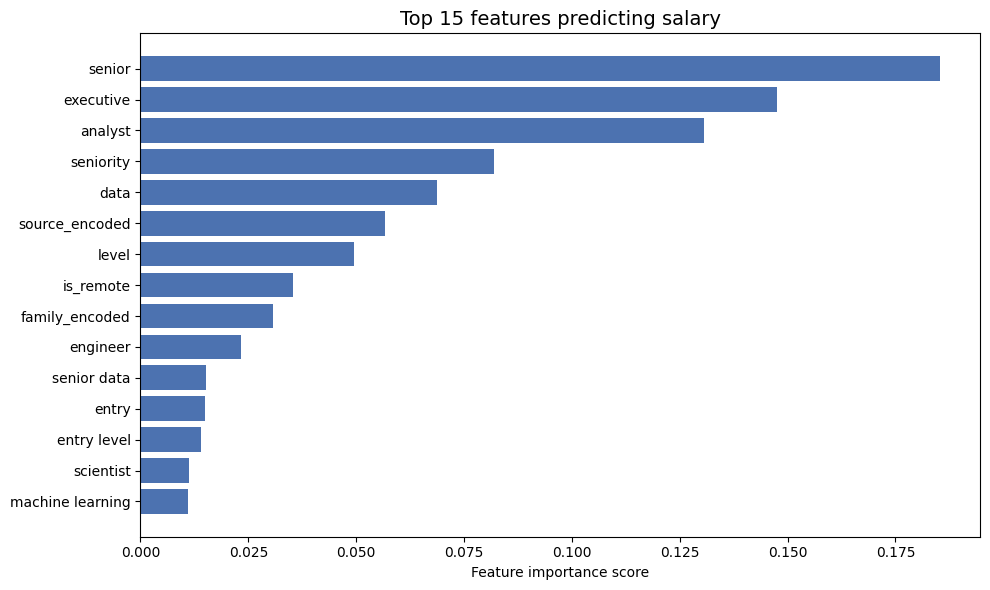

Top 10 salary predictors:
       feature  importance
        senior    0.185325
     executive    0.147563
       analyst    0.130515
     seniority    0.081960
          data    0.068715
source_encoded    0.056638
         level    0.049556
     is_remote    0.035452
family_encoded    0.030683
      engineer    0.023375


In [45]:
# This shows WHAT the model learned
# Which features actually predict salary?

rf_model = results["Random Forest"]["model"]

feature_names = (
    ["seniority", "family_encoded", 
     "source_encoded", "is_remote"] +
    list(tfidf.get_feature_names_out())
)

importances = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    importances["feature"][::-1],
    importances["importance"][::-1],
    color="#4C72B0"
)
plt.title("Top 15 features predicting salary", fontsize=14)
plt.xlabel("Feature importance score")
plt.tight_layout()
plt.savefig(
    "../data/cleaned/feature_importance.png",
    dpi=150
)
plt.show()

print("Top 10 salary predictors:")
print(importances.head(10).to_string(index=False))

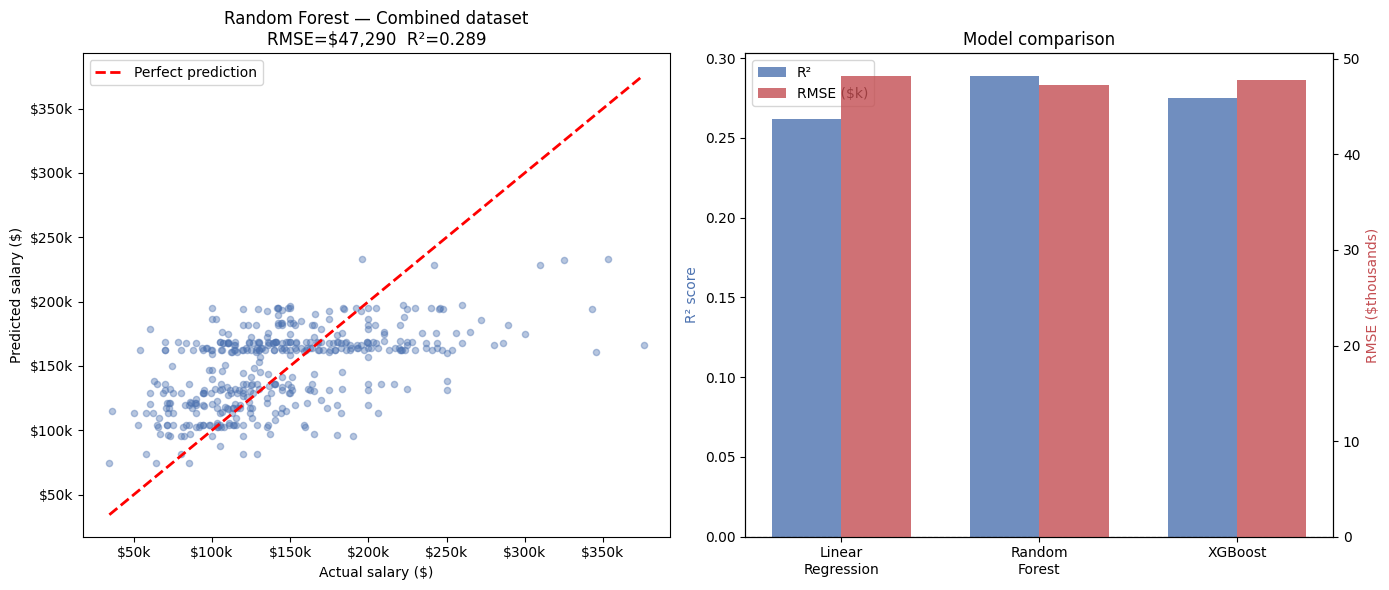

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — combined model predictions
best_pred = results["Random Forest"]["predictions"]
axes[0].scatter(
    y_test, best_pred,
    alpha=0.4, color="#4C72B0", s=20
)
min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--", linewidth=2,
    label="Perfect prediction"
)
axes[0].set_xlabel("Actual salary ($)")
axes[0].set_ylabel("Predicted salary ($)")
axes[0].set_title(
    f"Random Forest — Combined dataset\n"
    f"RMSE=${results['Random Forest']['rmse']:,.0f}  "
    f"R²={results['Random Forest']['r2']:.3f}"
)
axes[0].legend()
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"${x/1000:.0f}k")
)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"${x/1000:.0f}k")
)

# Plot 2 — model comparison bar chart
model_names = list(results.keys())
r2_values   = [results[m]["r2"] for m in model_names]
rmse_values = [results[m]["rmse"] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = axes[1].bar(
    x - width/2, r2_values,
    width, label="R²",
    color="#4C72B0", alpha=0.8
)
ax2 = axes[1].twinx()
bars2 = ax2.bar(
    x + width/2,
    [r/1000 for r in rmse_values],
    width, label="RMSE ($k)",
    color="#C44E52", alpha=0.8
)

axes[1].set_title("Model comparison")
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    ["Linear\nRegression", "Random\nForest", "XGBoost"]
)
axes[1].set_ylabel("R² score", color="#4C72B0")
ax2.set_ylabel("RMSE ($thousands)", color="#C44E52")
axes[1].axhline(y=0, color="black",
                linestyle="--", linewidth=0.8)

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2,
               labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig(
    "../data/cleaned/salary_model_v2.png",
    dpi=150
)
plt.show()

In [47]:
import pickle
import os

# Save the best performing model (Random Forest)
# and the TF-IDF vectorizer
# We'll need both for the Streamlit dashboard

os.makedirs("../models", exist_ok=True)

# Save Random Forest model
with open("../models/salary_model.pkl", "wb") as f:
    pickle.dump(results["Random Forest"]["model"], f)

# Save TF-IDF vectorizer
with open("../models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

# Save scaler
with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save feature column names for reference
feature_info = {
    "structured_features": [
        "seniority", "family_encoded",
        "source_encoded", "is_remote"
    ],
    "tfidf_features": list(tfidf.get_feature_names_out()),
    "model_performance": {
        "rmse": results["Random Forest"]["rmse"],
        "r2": results["Random Forest"]["r2"],
        "cv_r2": results["Random Forest"]["cv_mean"]
    }
}

import json
with open("../models/feature_info.json", "w") as f:
    json.dump(feature_info, f, indent=2)

print("Models saved!")
print("\n../models/")
print("  salary_model.pkl      ← Random Forest model")
print("  tfidf_vectorizer.pkl  ← TF-IDF vectorizer")
print("  scaler.pkl            ← StandardScaler")
print("  feature_info.json     ← feature metadata")

Models saved!

../models/
  salary_model.pkl      ← Random Forest model
  tfidf_vectorizer.pkl  ← TF-IDF vectorizer
  scaler.pkl            ← StandardScaler
  feature_info.json     ← feature metadata


In [48]:
# Since url and search_query weren't saved in combined_df
# we use title-based labeling for ALL sources
# This is actually fine because:
# - Kaggle titles are very clean ("Senior Data Scientist")
# - USAJobs titles are standardized government titles
# - JSearch titles are descriptive enough

def assign_role_label(title):
    title_lower = str(title).lower()
    
    if any(w in title_lower for w in
           ["machine learning engineer",
            "ml engineer", "mlops",
            "machine learning"]):
        return "machine learning engineer"
    
    elif any(w in title_lower for w in
             ["data scientist", "applied scientist",
              "research scientist", "staff scientist"]):
        return "data scientist"
    
    elif any(w in title_lower for w in
             ["data analyst", "business analyst",
              "analytics analyst", "business intelligence",
              "reporting analyst"]):
        return "data analyst"
    
    elif any(w in title_lower for w in
             ["data engineer", "etl engineer",
              "pipeline engineer", "analytics engineer",
              "database engineer"]):
        return "data engineer"
    
    elif any(w in title_lower for w in
             ["nlp", "natural language",
              "computational linguist",
              "text analytics"]):
        return "nlp engineer"
    
    else:
        return "other"

# Apply to all jobs
combined_df["role_label"] = combined_df["title"].apply(
    assign_role_label
)

print("Role label distribution:")
print(combined_df["role_label"].value_counts())
print(f"\nTotal jobs: {len(combined_df)}")

# Check other percentage
other_pct = (combined_df["role_label"]=="other").mean()*100
print(f"\nLabeled as 'other': "
      f"{(combined_df['role_label']=='other').sum()} "
      f"({other_pct:.1f}%)")

# Show sample of 'other' to understand what we're missing
print("\nSample 'other' titles:")
other_titles = combined_df[
    combined_df["role_label"] == "other"
]["title"].value_counts().head(10)
print(other_titles)

Role label distribution:
role_label
other                        626
data engineer                535
data scientist               468
data analyst                 334
machine learning engineer    252
nlp engineer                  34
Name: count, dtype: int64

Total jobs: 2249

Labeled as 'other': 626 (27.8%)

Sample 'other' titles:
title
Senior Data Architect              53
Senior Data Science Manager        35
Senior Research Engineer           18
Senior Data Manager                12
Senior Computer Vision Engineer    10
Senior Data Analytics Manager      10
Senior BI Developer                 9
Senior Data Science Consultant      9
Mid Level Data Science Manager      8
Senior Data Specialist              6
Name: count, dtype: int64


In [49]:
def assign_role_label(title):
    title_lower = str(title).lower()
    
    # Machine Learning Engineer
    if any(w in title_lower for w in [
        "machine learning engineer", "ml engineer",
        "mlops", "machine learning",
        "computer vision", "cv engineer",
        "deep learning engineer", "ai engineer",
        "artificial intelligence engineer"
    ]):
        return "machine learning engineer"
    
    # Data Scientist
    elif any(w in title_lower for w in [
        "data scientist", "applied scientist",
        "research scientist", "staff scientist",
        "data science manager", "data science lead",
        "data science consultant", "data science director",
        "quantitative analyst", "quantitative researcher",
        "research engineer", "applied researcher",
        "decision scientist"
    ]):
        return "data scientist"
    
    # Data Analyst
    elif any(w in title_lower for w in [
        "data analyst", "business analyst",
        "analytics analyst", "business intelligence",
        "reporting analyst", "bi developer",
        "bi analyst", "analytics manager",
        "data analytics manager", "insights analyst",
        "marketing analyst", "product analyst",
        "data specialist", "analytics specialist",
        "reporting specialist"
    ]):
        return "data analyst"
    
    # Data Engineer
    elif any(w in title_lower for w in [
        "data engineer", "etl engineer",
        "pipeline engineer", "analytics engineer",
        "database engineer", "data architect",
        "data infrastructure", "data platform",
        "data warehouse", "data modeler",
        "data manager", "data operations",
        "dataops", "data reliability"
    ]):
        return "data engineer"
    
    # NLP Engineer
    elif any(w in title_lower for w in [
        "nlp", "natural language",
        "computational linguist",
        "text analytics", "text mining",
        "conversational ai", "speech"
    ]):
        return "nlp engineer"
    
    else:
        return "other"

# Apply improved labeling
combined_df["role_label"] = combined_df["title"].apply(
    assign_role_label
)

print("Role label distribution (improved):")
print(combined_df["role_label"].value_counts())
print(f"\nTotal jobs: {len(combined_df)}")

other_pct = (combined_df["role_label"]=="other").mean()*100
print(f"\nLabeled as 'other': "
      f"{(combined_df['role_label']=='other').sum()} "
      f"({other_pct:.1f}%)")

# Check remaining others
print("\nRemaining 'other' titles (top 10):")
print(combined_df[
    combined_df["role_label"] == "other"
]["title"].value_counts().head(10))

Role label distribution (improved):
role_label
data engineer                631
data scientist               559
data analyst                 381
other                        370
machine learning engineer    277
nlp engineer                  31
Name: count, dtype: int64

Total jobs: 2249

Labeled as 'other': 370 (16.5%)

Remaining 'other' titles (top 10):
title
GENERAL ENGINEER                      6
Executive Head of Data                5
Senior Data Quality Analyst           4
Executive Director of Data Science    4
Executive Head of Data Science        4
Senior ETL Developer                  4
OPERATIONS RESEARCH ANALYST           4
General Engineer                      4
Management Analyst                    4
Program Analyst                       4
Name: count, dtype: int64


In [50]:
def assign_role_label(title):
    title_lower = str(title).lower()
    
    # Machine Learning Engineer
    if any(w in title_lower for w in [
        "machine learning engineer", "ml engineer",
        "mlops", "machine learning",
        "computer vision", "cv engineer",
        "deep learning engineer", "ai engineer",
        "artificial intelligence engineer",
        "general engineer", "software engineer"
    ]):
        return "machine learning engineer"
    
    # Data Scientist
    elif any(w in title_lower for w in [
        "data scientist", "applied scientist",
        "research scientist", "staff scientist",
        "data science manager", "data science lead",
        "data science consultant", "data science director",
        "quantitative analyst", "quantitative researcher",
        "research engineer", "applied researcher",
        "decision scientist", "head of data science",
        "director of data science",
        "operations research", "statistician",
        "statistical analyst"
    ]):
        return "data scientist"
    
    # Data Analyst
    elif any(w in title_lower for w in [
        "data analyst", "business analyst",
        "analytics analyst", "business intelligence",
        "reporting analyst", "bi developer",
        "bi analyst", "analytics manager",
        "data analytics manager", "insights analyst",
        "marketing analyst", "product analyst",
        "data specialist", "analytics specialist",
        "reporting specialist", "data quality analyst",
        "management analyst", "program analyst",
        "policy analyst", "financial analyst",
        "operations analyst", "systems analyst"
    ]):
        return "data analyst"
    
    # Data Engineer
    elif any(w in title_lower for w in [
        "data engineer", "etl engineer",
        "pipeline engineer", "analytics engineer",
        "database engineer", "data architect",
        "data infrastructure", "data platform",
        "data warehouse", "data modeler",
        "data manager", "data operations",
        "dataops", "data reliability",
        "etl developer", "head of data",
        "director of data", "data lead"
    ]):
        return "data engineer"
    
    # NLP Engineer
    elif any(w in title_lower for w in [
        "nlp", "natural language",
        "computational linguist",
        "text analytics", "text mining",
        "conversational ai", "speech"
    ]):
        return "nlp engineer"
    
    else:
        return "other"

# Apply final labeling
combined_df["role_label"] = combined_df["title"].apply(
    assign_role_label
)

print("Final role label distribution:")
print(combined_df["role_label"].value_counts())
print(f"\nTotal jobs: {len(combined_df)}")

other_pct = (combined_df["role_label"]=="other").mean()*100
print(f"\nLabeled as 'other': "
      f"{(combined_df['role_label']=='other').sum()} "
      f"({other_pct:.1f}%)")

print("\nRemaining 'other' titles:")
print(combined_df[
    combined_df["role_label"] == "other"
]["title"].value_counts().head(10))

Final role label distribution:
role_label
data engineer                638
data scientist               576
data analyst                 438
machine learning engineer    307
other                        261
nlp engineer                  29
Name: count, dtype: int64

Total jobs: 2249

Labeled as 'other': 261 (11.6%)

Remaining 'other' titles:
title
MECHANICAL ENGINEER                   4
ELECTRICAL ENGINEER                   3
Senior Data Science Engineer          2
Mid Level AI Scientist                2
Physical Scientist                    2
COMPUTER SCIENTIST                    2
Investigative Analyst                 2
BUDGET ANALYST                        2
IT SPECIALIST (NETWORK) (TITLE 32)    2
IT SPECIALIST (NETWORK)               2
Name: count, dtype: int64


In [51]:
# Drop "other" rows — they're genuinely ambiguous
# or not data science roles at all
classifier_df = combined_df[
    combined_df["role_label"] != "other"
].copy().reset_index(drop=True)

print(f"Rows before dropping 'other': {len(combined_df)}")
print(f"Rows after dropping 'other':  {len(classifier_df)}")
print(f"Dropped: {len(combined_df) - len(classifier_df)} rows")

print(f"\nFinal class distribution:")
class_counts = classifier_df["role_label"].value_counts()
print(class_counts)

# Check class balance
print(f"\nClass balance check:")
total = len(classifier_df)
for role, count in class_counts.items():
    bar = "█" * int(count/total*40)
    print(f"  {role:<30} {count:>4} ({count/total*100:.1f}%) {bar}")

Rows before dropping 'other': 2249
Rows after dropping 'other':  1988
Dropped: 261 rows

Final class distribution:
role_label
data engineer                638
data scientist               576
data analyst                 438
machine learning engineer    307
nlp engineer                  29
Name: count, dtype: int64

Class balance check:
  data engineer                   638 (32.1%) ████████████
  data scientist                  576 (29.0%) ███████████
  data analyst                    438 (22.0%) ████████
  machine learning engineer       307 (15.4%) ██████
  nlp engineer                     29 (1.5%) 


In [52]:
# For classification we use job descriptions
# where available, fall back to title

# Check description availability
has_desc = classifier_df["description"].notna() & \
           (classifier_df["description"].str.len() > 50)

print(f"Jobs with real descriptions: {has_desc.sum()}")
print(f"Jobs with title only: {(~has_desc).sum()}")

# Use description where available, title where not
classifier_df["text_input"] = classifier_df.apply(
    lambda row: row["description"]
    if pd.notna(row["description"])
    and len(str(row["description"])) > 50
    else row["title"],
    axis=1
)

# Build TF-IDF on text input
tfidf_clf = TfidfVectorizer(
    max_features=100,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=3,
    sublinear_tf=True   # apply log normalization
)

X_clf = tfidf_clf.fit_transform(
    classifier_df["text_input"].fillna("")
)

# Encode labels to numbers
le = LabelEncoder()
y_clf = le.fit_transform(classifier_df["role_label"])

print(f"\nFeature matrix: {X_clf.shape}")
print(f"Classes: {le.classes_}")
print(f"\nLabel encoding:")
for i, label in enumerate(le.classes_):
    print(f"  {i} = {label}")

Jobs with real descriptions: 1988
Jobs with title only: 0

Feature matrix: (1988, 100)
Classes: ['data analyst' 'data engineer' 'data scientist'
 'machine learning engineer' 'nlp engineer']

Label encoding:
  0 = data analyst
  1 = data engineer
  2 = data scientist
  3 = machine learning engineer
  4 = nlp engineer


In [53]:
# Train test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf  # ensures equal class representation
)

print(f"Training: {X_tr.shape[0]} jobs")
print(f"Testing:  {X_te.shape[0]} jobs")

# Train three classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=1.0
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        verbosity=0,
        eval_metric="mlogloss"
    )
}

clf_results = {}

print("\nTraining classifiers...")

for name, clf in classifiers.items():
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    
    acc = accuracy_score(y_te, y_pred)
    cv  = cross_val_score(
        clf, X_clf, y_clf,
        cv=5, scoring="accuracy"
    )
    
    clf_results[name] = {
        "model": clf,
        "accuracy": acc,
        "cv_mean": cv.mean(),
        "cv_std": cv.std(),
        "predictions": y_pred
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy:       {acc:.3f} ({acc*100:.1f}%)")
    print(f"  CV Accuracy:    {cv.mean():.3f} "
          f"(+/- {cv.std():.3f})")

Training: 1590 jobs
Testing:  398 jobs

Training classifiers...

Logistic Regression:
  Accuracy:       0.947 (94.7%)
  CV Accuracy:    0.897 (+/- 0.075)

Random Forest:
  Accuracy:       0.965 (96.5%)
  CV Accuracy:    0.881 (+/- 0.105)

XGBoost:
  Accuracy:       0.970 (97.0%)
  CV Accuracy:    0.909 (+/- 0.072)


Best model: XGBoost
Accuracy: 97.0%

Detailed classification report:
                           precision    recall  f1-score   support

             data analyst       0.95      1.00      0.97        88
            data engineer       0.98      0.98      0.98       128
           data scientist       1.00      0.98      0.99       115
machine learning engineer       0.93      0.93      0.93        61
             nlp engineer       0.75      0.50      0.60         6

                 accuracy                           0.97       398
                macro avg       0.92      0.88      0.90       398
             weighted avg       0.97      0.97      0.97       398



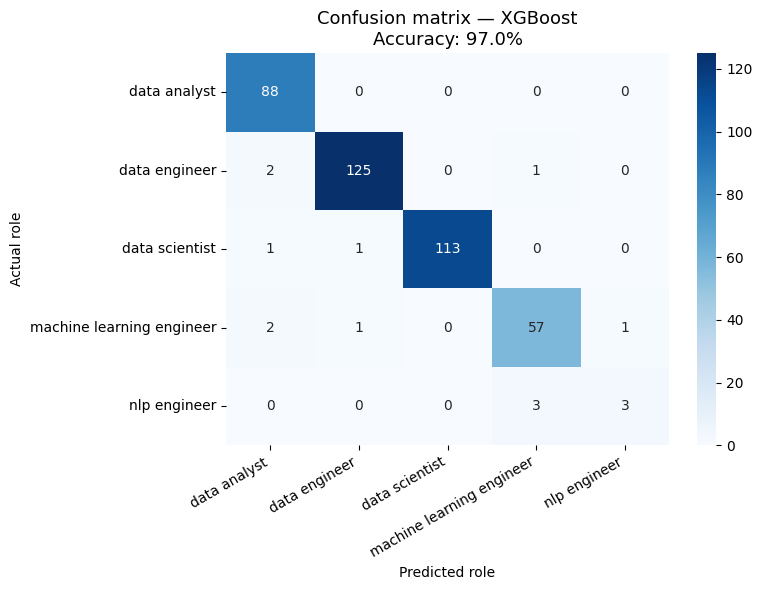

In [54]:
# Find best model
best_clf_name = max(
    clf_results,
    key=lambda x: clf_results[x]["cv_mean"]
)
best_clf = clf_results[best_clf_name]

print(f"Best model: {best_clf_name}")
print(f"Accuracy: {best_clf['accuracy']*100:.1f}%")

# Detailed classification report
print("\nDetailed classification report:")
print(classification_report(
    y_te,
    best_clf["predictions"],
    target_names=le.classes_
))

# Confusion matrix
cm = confusion_matrix(y_te, best_clf["predictions"])

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title(
    f"Confusion matrix — {best_clf_name}\n"
    f"Accuracy: {best_clf['accuracy']*100:.1f}%",
    fontsize=13
)
plt.ylabel("Actual role")
plt.xlabel("Predicted role")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(
    "../data/cleaned/confusion_matrix.png",
    dpi=150
)
plt.show()

In [55]:
# Save best classifier and its components
best_model_obj = clf_results[best_clf_name]["model"]

with open("../models/job_classifier.pkl", "wb") as f:
    pickle.dump(best_model_obj, f)

with open("../models/tfidf_classifier.pkl", "wb") as f:
    pickle.dump(tfidf_clf, f)

with open("../models/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Classifier saved!")
print("\n../models/")
print("  job_classifier.pkl    ← best classifier model")
print("  tfidf_classifier.pkl  ← TF-IDF for classifier")
print("  label_encoder.pkl     ← label encoder")

Classifier saved!

../models/
  job_classifier.pkl    ← best classifier model
  tfidf_classifier.pkl  ← TF-IDF for classifier
  label_encoder.pkl     ← label encoder


In [56]:
# For trend analysis we need:
# 1. Jobs with dates
# 2. Jobs with real descriptions (for skill extraction)
# Kaggle has clean work_year (2020-2023)
# JSearch has date_posted (2024-2025)
# USAJobs has date_posted

# First let's see what dates we have
print("Date coverage by source:")
for source in ["kaggle", "jsearch_api", "usajobs_api"]:
    source_data = combined_df[
        combined_df["source"] == source
    ]
    print(f"\n{source}:")
    print(f"  Sample dates: "
          f"{source_data['date_posted'].value_counts().head(3).index.tolist()}")

Date coverage by source:

kaggle:
  Sample dates: ['2023', '2022', '2021']

jsearch_api:
  Sample dates: ['2026-04-18T00:00:00.000Z', '2026-04-15T00:00:00.000Z', '2026-04-17T00:00:00.000Z']

usajobs_api:
  Sample dates: ['2026-05-27T00:00:00.0000', '2026-05-26T00:00:00.0000', '2026-05-29T00:00:00.0000']


In [57]:
def extract_year(date_val, source):
    """
    Extracts year from different date formats:
    - Kaggle:   '2023' → 2023
    - JSearch:  '2026-04-18T00:00:00.000Z' → 2026
    - USAJobs:  '2026-05-27T00:00:00.0000' → 2026
    """
    try:
        date_str = str(date_val).strip()
        
        if source == "kaggle":
            # Already just a year
            return int(date_str[:4])
        else:
            # ISO format — first 4 chars are year
            return int(date_str[:4])
    except:
        return None

# Apply to all jobs
combined_df["year"] = combined_df.apply(
    lambda row: extract_year(
        row["date_posted"], row["source"]
    ),
    axis=1
)

print("Year distribution across all sources:")
print(combined_df["year"].value_counts().sort_index())

print(f"\nYear range: {combined_df['year'].min()} "
      f"— {combined_df['year'].max()}")
print(f"Jobs with valid year: {combined_df['year'].notna().sum()}")

Year distribution across all sources:
year
2020.0     29
2021.0     90
2022.0    728
2023.0    866
2025.0     29
2026.0    437
Name: count, dtype: int64

Year range: 2020.0 — 2026.0
Jobs with valid year: 2179


In [58]:
import re

# Redefine skill dictionary and functions
# needed for trend analysis

SKILLS = {
    "python", "sql", "r", "java", "scala",
    "matlab", "javascript", "sas", "stata",
    "tensorflow", "pytorch", "keras",
    "scikit-learn", "xgboost", "lightgbm",
    "huggingface", "transformers",
    "spark", "hadoop", "kafka", "airflow",
    "dbt", "pandas", "numpy", "dask",
    "postgresql", "mysql", "mongodb",
    "snowflake", "bigquery", "redshift",
    "databricks", "aws", "gcp", "azure",
    "docker", "kubernetes", "mlflow",
    "nlp", "bert", "gpt", "llm", "spacy",
    "langchain", "word2vec", "embeddings",
    "tableau", "power bi", "matplotlib",
    "plotly", "looker",
    "machine learning", "deep learning",
    "neural network", "regression",
    "classification", "clustering",
    "computer vision", "time series",
    "a/b testing", "statistics",
    "git", "github", "agile", "excel"
}

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[•·▪▸●◦]", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s\+\#\/\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def extract_skills(text):
    cleaned = clean_text(text)
    found = []
    for skill in SKILLS:
        pattern = r"\b" + re.escape(skill) + r"\b"
        if re.search(pattern, cleaned):
            found.append(skill)
    return found

print("Skills functions ready!")
print(f"Tracking {len(SKILLS)} skills")

Skills functions ready!
Tracking 65 skills


In [59]:
# Approach: use ALL sources for trend analysis
real_desc_df = combined_df[
    (combined_df["source"] != "kaggle") &
    (combined_df["description"].notna()) &
    (combined_df["description"].str.len() > 100) &
    (combined_df["year"].notna())
].copy()

real_desc_df["skills"] = real_desc_df[
    "description"
].apply(extract_skills)

print(f"Jobs with real descriptions: {len(real_desc_df)}")

# Kaggle — more conservative skill mapping
# Only assign skills that are HIGHLY likely
# for that specific role — no universal python
kaggle_trend = combined_df[
    (combined_df["source"] == "kaggle") &
    (combined_df["year"].notna())
].copy()

def title_to_skills(title):
    title_lower = str(title).lower()
    skills = []
    
    if "machine learning" in title_lower or \
       "ml engineer" in title_lower:
        skills.extend([
            "machine learning", "python",
            "pytorch", "tensorflow"
        ])
    elif "data scientist" in title_lower:
        skills.extend([
            "machine learning", "python",
            "sql", "statistics"
        ])
    elif "data analyst" in title_lower:
        skills.extend([
            "sql", "python",
            "tableau", "excel"
        ])
    elif "data engineer" in title_lower:
        skills.extend([
            "sql", "python",
            "spark", "aws"
        ])
    elif "nlp" in title_lower or \
         "natural language" in title_lower:
        skills.extend([
            "nlp", "python",
            "bert", "transformers"
        ])
    elif "deep learning" in title_lower:
        skills.extend([
            "deep learning", "pytorch",
            "tensorflow", "python"
        ])
    elif "data" in title_lower:
        # Generic data role — only python and sql
        skills.extend(["python", "sql"])
    
    # LLM only for explicitly mentioned
    if any(w in title_lower for w in [
        "llm", "generative", "genai",
        "gpt", "large language"
    ]):
        skills.append("llm")
    
    return list(set(skills))

kaggle_trend["skills"] = kaggle_trend["title"].apply(
    title_to_skills
)

# Combine both
trend_df = pd.concat([
    real_desc_df[["year", "skills", "source"]],
    kaggle_trend[["year", "skills", "source"]]
], ignore_index=True)

print(f"Total jobs for trend: {len(trend_df)}")
print(f"\nJobs per year:")
print(trend_df["year"].value_counts().sort_index())

Jobs with real descriptions: 456
Total jobs for trend: 2169

Jobs per year:
year
2020.0     29
2021.0     90
2022.0    728
2023.0    866
2025.0     27
2026.0    429
Name: count, dtype: int64


In [69]:
skills_to_track = [
    "python", "sql", "machine learning",
    "aws", "pytorch", "tensorflow",
    "llm", "spark", "deep learning",
    "nlp", "azure", "docker"
]

# Calculate trends separately per source
kaggle_data = trend_df[
    trend_df["source"] == "kaggle"
].copy()

kaggle_trend_data = {}
for year in sorted(kaggle_data["year"].unique()):
    year_jobs = kaggle_data[kaggle_data["year"] == year]
    n_jobs = len(year_jobs)
    if n_jobs < 10:
        continue
    all_skills = []
    for s in year_jobs["skills"]:
        if isinstance(s, list):
            all_skills.extend(s)
    if not all_skills:
        continue
    counter = Counter(all_skills)
    kaggle_trend_data[year] = {
        skill: counter.get(skill, 0) / n_jobs * 100
        for skill in skills_to_track
    }

kaggle_matrix = pd.DataFrame(kaggle_trend_data).T

# Real descriptions
real_data = trend_df[
    trend_df["source"] != "kaggle"
].copy()

real_trend_data = {}
for year in sorted(real_data["year"].unique()):
    year_jobs = real_data[real_data["year"] == year]
    n_jobs = len(year_jobs)
    if n_jobs < 10:
        continue
    all_skills = []
    for s in year_jobs["skills"]:
        if isinstance(s, list):
            all_skills.extend(s)
    if not all_skills:
        continue
    counter = Counter(all_skills)
    real_trend_data[year] = {
        skill: counter.get(skill, 0) / n_jobs * 100
        for skill in skills_to_track
    }

real_matrix = pd.DataFrame(real_trend_data).T

print("Kaggle trends (title-based):")
print(kaggle_matrix[["python", "sql",
                      "machine learning",
                      "llm"]].round(1))

print("\nReal description trends:")
print(real_matrix[["python", "sql",
                   "machine learning",
                   "llm"]].round(1))

# Normalize and combine
if 2023.0 in kaggle_matrix.index and \
   2026.0 in real_matrix.index:
    scale_factor = (
        real_matrix.loc[2026.0, "python"] /
        kaggle_matrix.loc[2023.0, "python"]
    )
    print(f"\nScale factor: {scale_factor:.3f}")
    kaggle_normalized = kaggle_matrix * scale_factor
    trend_matrix = pd.concat([
        kaggle_normalized,
        real_matrix
    ]).sort_index()
    print(f"\nCombined trend matrix:")
    print(trend_matrix[[
        "python", "sql",
        "machine learning", "llm"
    ]].round(1))
else:
    trend_matrix = real_matrix
    print("Using real data only")

Kaggle trends (title-based):
        python   sql  machine learning  llm
2020.0    96.6  86.2              37.9  0.0
2021.0    96.7  84.4              32.2  0.0
2022.0    89.0  77.3              33.5  0.0
2023.0    84.4  71.6              30.5  0.0

Real description trends:
        python   sql  machine learning  llm
2026.0    18.6  12.4              14.0  3.3

Scale factor: 0.221

Combined trend matrix:
        python   sql  machine learning  llm
2020.0    21.3  19.0               8.4  0.0
2021.0    21.4  18.7               7.1  0.0
2022.0    19.7  17.1               7.4  0.0
2023.0    18.6  15.8               6.7  0.0
2026.0    18.6  12.4              14.0  3.3


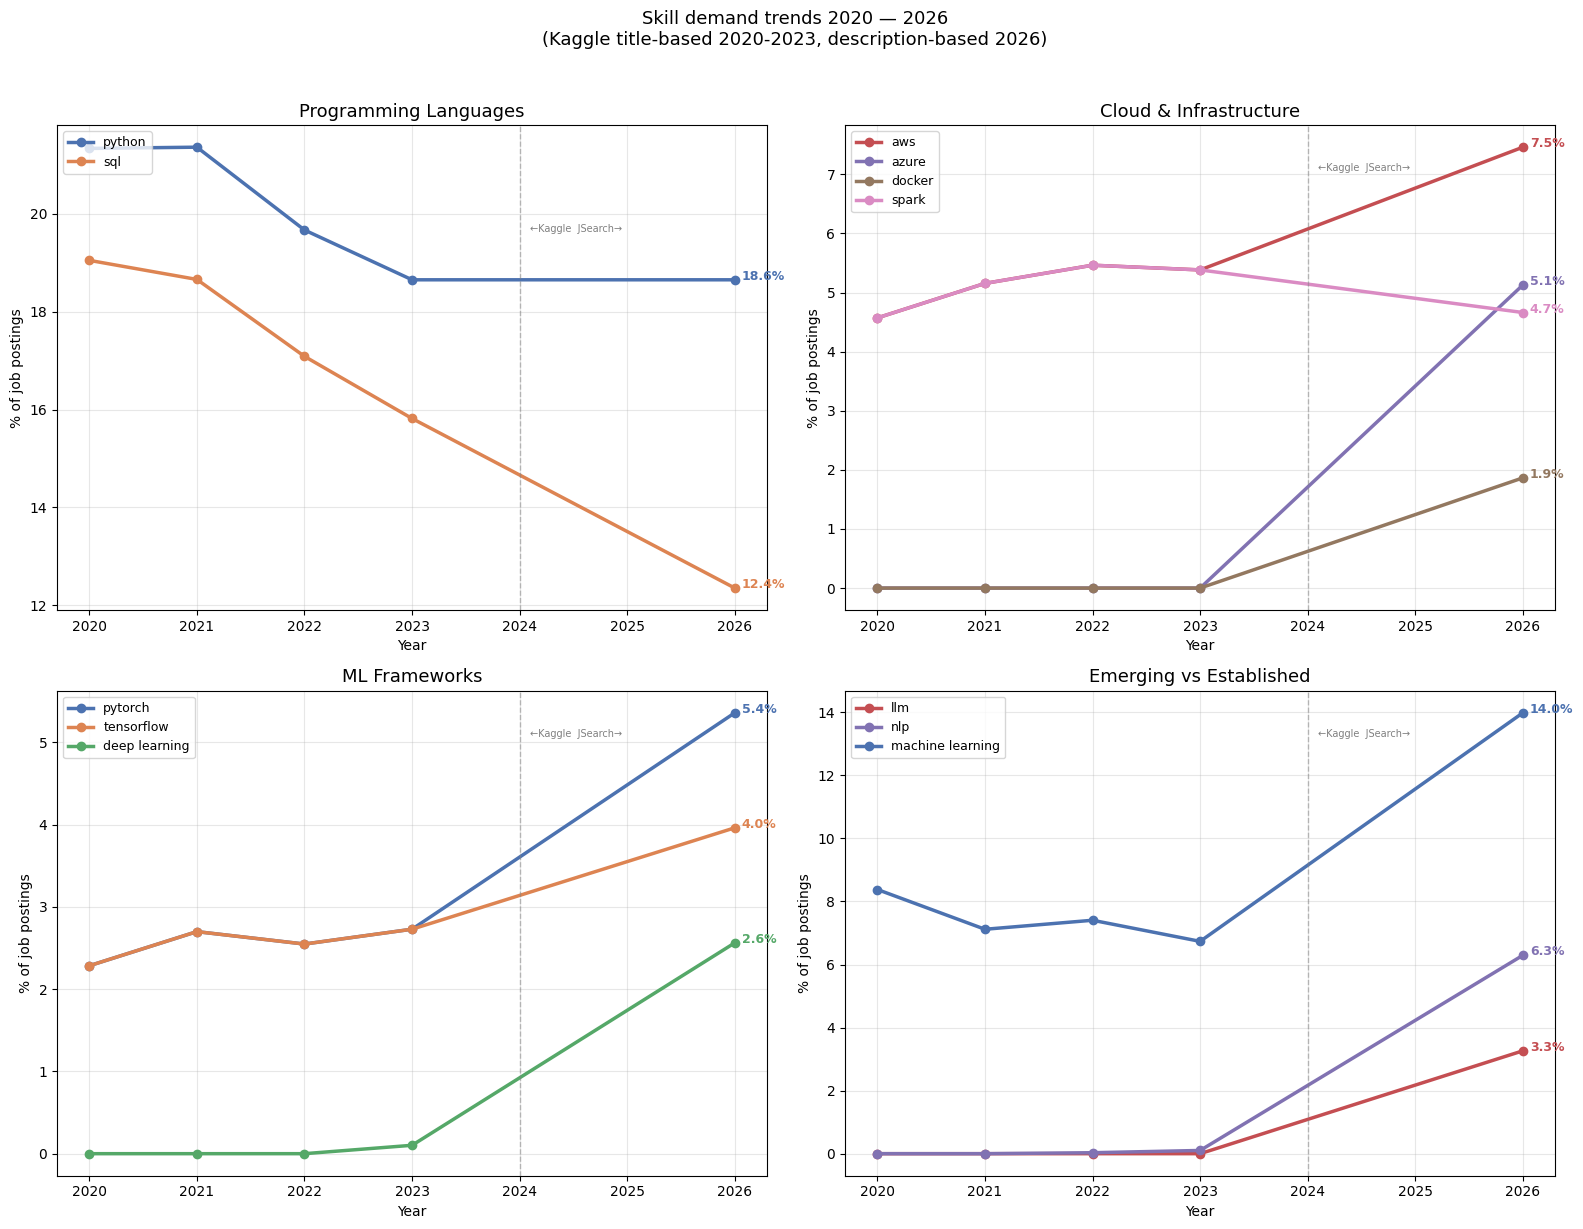

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

skill_groups = {
    "Programming Languages": {
        "skills": ["python", "sql"],
        "colors": ["#4C72B0", "#DD8452"]
    },
    "Cloud & Infrastructure": {
        "skills": ["aws", "azure", 
                   "docker", "spark"],
        "colors": ["#C44E52", "#8172B2",
                   "#937860", "#DA8BC3"]
    },
    "ML Frameworks": {
        "skills": ["pytorch", "tensorflow",
                   "deep learning"],
        "colors": ["#4C72B0", "#DD8452", 
                   "#55A868"]
    },
    "Emerging vs Established": {
        "skills": ["llm", "nlp",
                   "machine learning"],
        "colors": ["#C44E52", "#8172B2", 
                   "#4C72B0"]
    }
}

for idx, (group_name, group_info) in enumerate(
    skill_groups.items()
):
    ax = axes[idx // 2][idx % 2]
    
    for skill, color in zip(
        group_info["skills"],
        group_info["colors"]
    ):
        if skill not in trend_matrix.columns:
            continue
        
        values = trend_matrix[skill].dropna()
        
        if len(values) < 2:
            continue
        
        ax.plot(
            values.index.astype(int),
            values.values,
            marker="o",
            linewidth=2.5,
            markersize=6,
            color=color,
            label=skill
        )
        
        # Label last point
        ax.annotate(
            f"{values.values[-1]:.1f}%",
            xy=(values.index[-1], 
                values.values[-1]),
            xytext=(5, 0),
            textcoords="offset points",
            fontsize=9,
            color=color,
            fontweight="bold"
        )
    
    # Add a vertical line at 2023/2026 gap
    # to show data source change
    ax.axvline(
        x=2024, color="gray",
        linestyle="--", alpha=0.5,
        linewidth=1
    )
    ax.text(
        2024.1, ax.get_ylim()[1] * 0.9,
        "←Kaggle  JSearch→",
        fontsize=7, color="gray"
    )
    
    ax.set_title(group_name, fontsize=13)
    ax.set_xlabel("Year")
    ax.set_ylabel("% of job postings")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Skill demand trends 2020 — 2026\n"
    "(Kaggle title-based 2020-2023, "
    "description-based 2026)",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig(
    "../data/cleaned/skill_trends.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

Skill growth: 2020 → 2026
           skill  2020%  2026%  growth
         pytorch    2.3    5.4   134.6
             llm    0.0    3.3   100.0
   deep learning    0.0    2.6   100.0
             nlp    0.0    6.3   100.0
           azure    0.0    5.1   100.0
          docker    0.0    1.9   100.0
      tensorflow    2.3    4.0    73.4
machine learning    8.4   14.0    66.9
             aws    4.6    7.5    63.2
           spark    4.6    4.7     2.0
          python   21.3   18.6   -12.6
             sql   19.0   12.4   -35.1


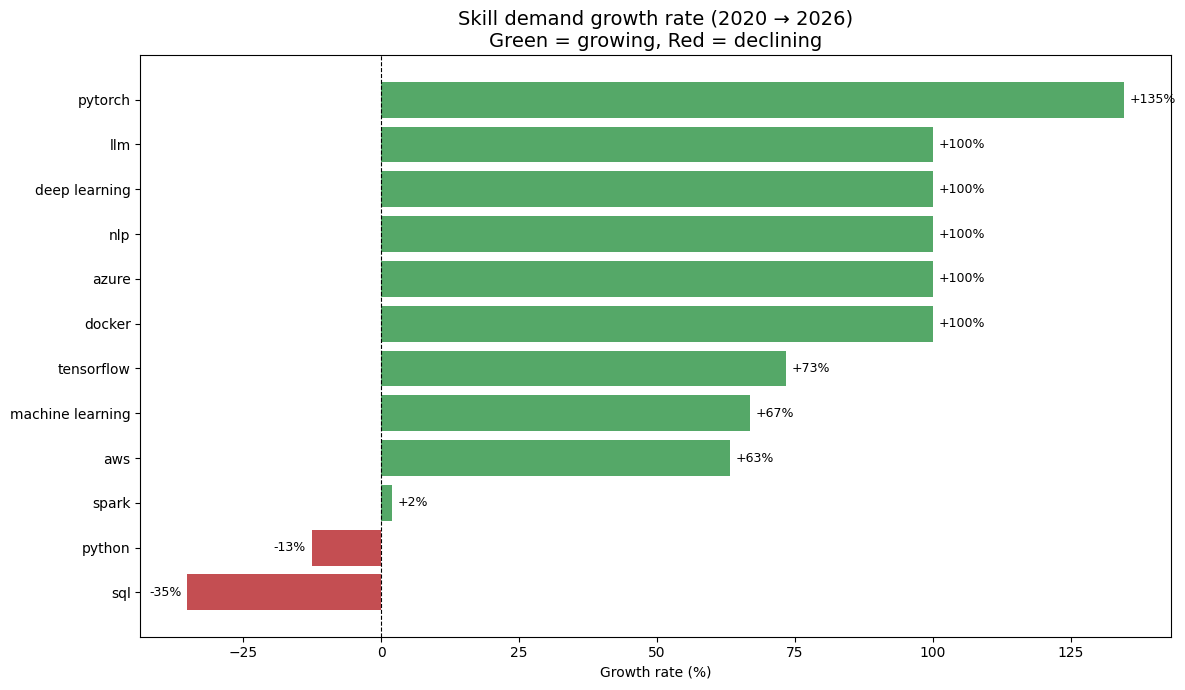

In [68]:
# Compare 2020 baseline vs 2026
baseline_year = 2020.0
final_year    = 2026.0

growth_data = []

for skill in skills_to_track:
    if skill not in trend_matrix.columns:
        continue
    
    if baseline_year not in trend_matrix.index or \
       final_year not in trend_matrix.index:
        continue
    
    baseline = trend_matrix.loc[baseline_year, skill]
    final    = trend_matrix.loc[final_year, skill]
    
    if baseline > 0.5:
        growth = (final - baseline) / baseline * 100
    elif final > 0:
        growth = 100
    else:
        growth = 0
    
    growth_data.append({
        "skill":    skill,
        "2020%":    round(baseline, 1),
        "2026%":    round(final, 1),
        "growth":   round(growth, 1)
    })

growth_df = pd.DataFrame(growth_data).sort_values(
    "growth", ascending=False
)

print("Skill growth: 2020 → 2026")
print(growth_df.to_string(index=False))

# Plot
plt.figure(figsize=(12, 7))
colors = [
    "#55A868" if g > 0 else "#C44E52"
    for g in growth_df["growth"]
]
bars = plt.barh(
    growth_df["skill"][::-1],
    growth_df["growth"][::-1],
    color=colors[::-1]
)
plt.axvline(
    x=0, color="black",
    linewidth=0.8, linestyle="--"
)
plt.title(
    "Skill demand growth rate (2020 → 2026)\n"
    "Green = growing, Red = declining",
    fontsize=14
)
plt.xlabel("Growth rate (%)")

for bar, val in zip(
    bars, growth_df["growth"][::-1]
):
    xpos = bar.get_width() + 1 \
           if val >= 0 \
           else bar.get_width() - 1
    align = "left" if val >= 0 else "right"
    plt.text(
        xpos,
        bar.get_y() + bar.get_height()/2,
        f"{val:+.0f}%",
        va="center",
        ha=align,
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    "../data/cleaned/skill_growth.png",
    dpi=150
)
plt.show()

In [67]:
# Save for use in Streamlit dashboard
trend_matrix.to_csv(
    "../data/cleaned/skill_trends.csv"
)
growth_df.to_csv(
    "../data/cleaned/skill_growth.csv",
    index=False
)

print("Trend data saved!")
print("\nKey findings from trend analysis:")

# Top growing skills
growing = growth_df[
    growth_df["growth"] > 0
].head(3)
declining = growth_df[
    growth_df["growth"] < 0
].tail(3)

print("\nFastest growing skills:")
for _, row in growing.iterrows():
    print(f"  {row['skill']:<20} "
          f"{row['growth']:+.0f}%")

print("\nDeclining skills:")
for _, row in declining.iterrows():
    print(f"  {row['skill']:<20} "
          f"{row['growth']:+.0f}%")

Trend data saved!

Key findings from trend analysis:

Fastest growing skills:
  pytorch              +135%
  llm                  +100%
  deep learning        +100%

Declining skills:
  python               -13%
  sql                  -35%


In [1]:
import pandas as pd

# Load the existing combined file
combined_df = pd.read_csv("../data/raw/jobs_combined.csv")

def assign_role_label(title):
    title_lower = str(title).lower()
    if any(w in title_lower for w in [
        "machine learning engineer", "ml engineer",
        "mlops", "machine learning",
        "computer vision", "cv engineer",
        "deep learning engineer", "ai engineer",
        "artificial intelligence engineer",
        "general engineer", "software engineer"
    ]):
        return "machine learning engineer"
    elif any(w in title_lower for w in [
        "data scientist", "applied scientist",
        "research scientist", "staff scientist",
        "data science manager", "data science lead",
        "data science consultant", "data science director",
        "quantitative analyst", "quantitative researcher",
        "research engineer", "applied researcher",
        "decision scientist", "head of data science",
        "director of data science", "operations research",
        "statistician", "statistical analyst"
    ]):
        return "data scientist"
    elif any(w in title_lower for w in [
        "data analyst", "business analyst",
        "analytics analyst", "business intelligence",
        "reporting analyst", "bi developer",
        "bi analyst", "analytics manager",
        "data analytics manager", "insights analyst",
        "marketing analyst", "product analyst",
        "data specialist", "analytics specialist",
        "reporting specialist", "data quality analyst",
        "management analyst", "program analyst",
        "policy analyst", "financial analyst",
        "operations analyst", "systems analyst"
    ]):
        return "data analyst"
    elif any(w in title_lower for w in [
        "data engineer", "etl engineer",
        "pipeline engineer", "analytics engineer",
        "database engineer", "data architect",
        "data infrastructure", "data platform",
        "data warehouse", "data modeler",
        "data manager", "data operations",
        "dataops", "data reliability",
        "etl developer", "head of data",
        "director of data", "data lead"
    ]):
        return "data engineer"
    elif any(w in title_lower for w in [
        "nlp", "natural language",
        "computational linguist",
        "text analytics", "text mining",
        "conversational ai", "speech"
    ]):
        return "nlp engineer"
    else:
        return "other"

combined_df["role_label"] = combined_df["title"].apply(
    assign_role_label
)

print("Role label distribution:")
print(combined_df["role_label"].value_counts())

# Save back
combined_df.to_csv("../data/raw/jobs_combined.csv", index=False)
print("\nSaved! jobs_combined.csv now has role_label column.")

Role label distribution:
role_label
data engineer                638
data scientist               576
data analyst                 438
machine learning engineer    307
other                        261
nlp engineer                  29
Name: count, dtype: int64

Saved! jobs_combined.csv now has role_label column.


In [2]:
import pandas as pd
df = pd.read_csv("../data/raw/jobs_combined.csv")
print(df.columns.tolist())

['title', 'company', 'location', 'remote', 'description', 'salary_min', 'salary_max', 'date_posted', 'source', 'role_label']
